# Cramer-Lao Lower Bound

Lower bound for the detection on noisy, pixelated images

* dependent on noise, amplitude, z

Take the data model from [J. Chao, et al., *Fisher information theory for parameter estimation in single molecule microscopy: tutorial*, J. Opt. Soc. Am. A 33, B36 (2016).](https://opg.optica.org/abstract.cfm?URI=josaa-33-7-B36).

Eq. 29 states, the Fisher information matrix for a noisy, pixellated image as

$$
\mathbf{I}(\theta) = \sum_{k=1}^K \left(\frac{\partial\nu_{\theta,k}}{\partial\theta}\right)^T \left(\frac{\partial\nu_{\theta,k}}{\partial\theta}\right) \cdot \mathrm{E}\left[\left(\frac{\partial\ln\mathcal{p}_{\theta,k}(z)}{\partial\nu_{\theta,k}}\right)^2\right],
$$

for the parameter vector $\theta$, pixels $k=0,...,K$, mean photoelectron count $\nu_{\theta,k}$ and probability distribution $\mathcal{p}_{\theta,k}(z_k)$ that models the photoelectron count $z_k$ for pixel $k$.

In our simplified model, the photoelectron count is Gaussian distributed with mean $\nu_{\theta,k}$ and standard deviation $\sigma_{\theta,k}\equiv\sigma$.
Thus,

$$
\mathrm{E}\left[\left(\frac{\partial\ln\mathcal{p}_{\theta,k}(z)}{\partial\nu_{\theta,k}}\right)^2\right] = \mathrm{E}\left[\frac{(z_k-\nu_{\theta,k})^2}{\sigma^4}\right] = \frac{1}{\sigma^4} \mathrm{E}[(z_k-\nu_{\theta,k})^2] = \frac{1}{\sigma^2},
$$

and the Fisher information matrix becomes

$$
\mathbf{I}(\theta) = \frac{1}{\sigma^2} \sum_{k=1}^K \left(\frac{\partial\nu_{\theta,k}}{\partial\theta}\right)^T \left(\frac{\partial\nu_{\theta,k}}{\partial\theta}\right).
$$

The Cramer-Lao lower bound (CLLB) for the variance of the estimator $\hat{\theta}$ is then given by the inverse of this matrix:

$$
\text{Var}(\hat{\theta}) \geq \mathcal{I}(\theta)^{-1}
$$

Next, we calculate the CLLB for our PSF:

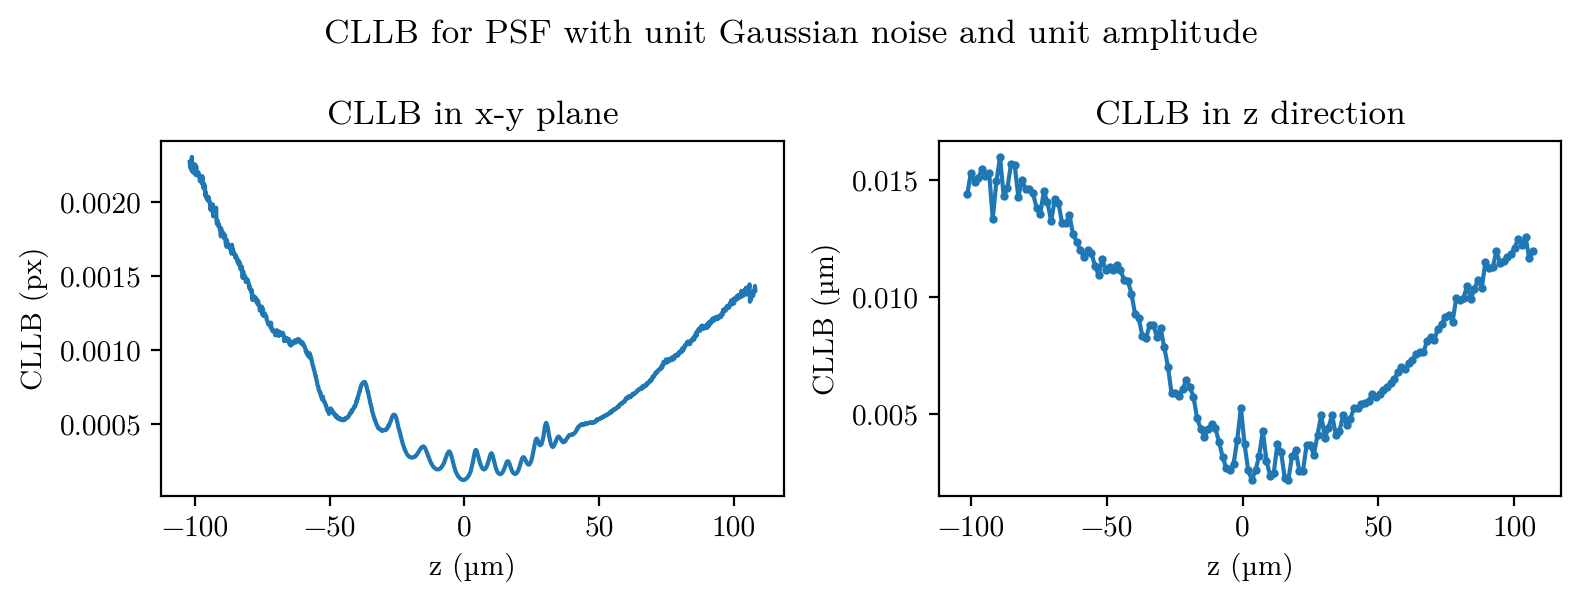

In [ ]:
import numpy as np
from numba import njit
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift
from scipy.optimize import curve_fit

import sys
if ".." not in sys.path: sys.path.append("..")
import image_generator as ig
from tqdm import tqdm

# Parameters
AMP = 1              # Amplitude of the PSF
sigma_noise = 1       # Std dev of Gaussian noise
psf = np.load("../ripples_downsampled.npy")  # Load PSF data

# Numerical derivatives w.r.t. x and y
def derivative(psf, z, axis, delta=1e-2): # delta : small shift in x or y
    shift_vec = [0, 0]
    shift_vec[axis] = delta
    psf_forward = (1-delta)*psf[z]+delta*np.roll(psf[z], shift=1, axis=axis)
    shift_vec[axis] = -delta
    psf_backward = (1-delta)*psf[z]+delta*np.roll(psf[z], shift=-1, axis=axis)
    return (psf_forward - psf_backward) / (2 * delta)

def derivative_z(psf, z, alpha=1e-2): # alpha : small shift in z
    if z <1 and z > psf.shape[0]-2:
        raise ValueError("z must be between 1 and psf.shape[0]-2")
    psf_forward =  (psf[z].T*(1-alpha) + psf[z-1].T*alpha).T
    psf_backward = (psf[z].T*(1-alpha) + psf[z+1].T*alpha).T
    delta_z = 1.134*alpha #um
    return (psf_forward - psf_backward) / (2 * delta_z)

def compute_cllb(z):
    dh_dx = derivative(psf,z, axis=1)  # x-axis derivative
    dh_dy = derivative(psf,z, axis=0)  # y-axis derivative
    dh_dz = derivative_z(psf,z)  # z-axis derivative

    # Compute Fisher Information Matrix (FIM)
    I_xx =  np.sum(dh_dx**2)
    I_yy =  np.sum(dh_dy**2)
    I_zz =  np.sum(dh_dz**2)


    I_xy =  np.sum(dh_dx * dh_dy)
    I_xz =  np.sum(dh_dx * dh_dz)
    I_yz =  np.sum(dh_dy * dh_dz)

    FIM = np.array([[I_xx, I_xy, I_xz],
                    [I_xy, I_yy, I_yz],
                    [I_xz, I_yz, I_zz]])

    CLLB = np.diag(np.linalg.inv(FIM))
    return sigma_noise/AMP *np.sqrt(CLLB)

# # Output results
# print("Fisher Information Matrix:\
# n", FIM)
# print("CLLB Covariance Matrix:\n", CLLB)



z_index = np.arange(1, 1566)
z_space = np.linspace(-102, 108, 1565)


std_x, std_y, std_z = np.array([compute_cllb(z_i) for z_i in z_index]).T
std_xy = np.sqrt((std_x**2+std_y**2)/2)

# Optional: visualize
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(z_space, std_xy)
plt.xlabel("z (µm)")
plt.ylabel("CLLB (px)")
plt.title("CLLB in x-y plane")
plt.subplot(1,2,2)
k=10
plt.plot(z_space[k//2:-k//2:k], np.convolve(std_z, np.ones(k)/k, mode='same')[k//2:-k//2:k], ".-",ms=4)
plt.xlabel("z (µm)")
plt.ylabel("CLLB (µm)")
plt.title("CLLB in z direction")
plt.suptitle("CLLB for PSF with unit Gaussian noise and unit amplitude")
plt.tight_layout()
plt.show()

# Save the results
np.savez("cllb_results.npz", z_space=z_space, std_z=std_z, std_xy=std_xy)

sampling absolute noise levels for different SNRs

In [42]:


ripple_params = {"label":"Ripple", "i":("gaussian", [0.75,0.25]), "z":[0,1567], "n":(30,90)}
parameter_list = [ripple_params, ]
image_size = 540,640            # Dimension 


snr_range = [1,18]
snrlevels = np.linspace(*snr_range, 18)
mean_noise = []
median_noise = []
for snr in snrlevels:
    print(f"Simulating for SNR: {snr}")
    noise = []
    numbers = []
    for i in range(500):
        n = np.random.randint(*ripple_params["n"])
        z = np.random.randint(*ripple_params["z"], n)
        ripples = psf[z]-2e4 #shape (n, 540, 640)
        intensities = np.random.normal(*ripple_params["i"][1], n)
        signal = np.max(np.abs(intensities*ripples.T).T, (1,2)) #max difference from background for each particle
        noise_std = np.mean(signal) / snr
        noise.append(noise_std)
        numbers.append(n)
    noise = np.array(noise)
    mean_noise.append(noise.mean())
    median_noise.append(np.median(noise))

Simulating for SNR: 1.0
Simulating for SNR: 2.0
Simulating for SNR: 3.0
Simulating for SNR: 4.0
Simulating for SNR: 5.0
Simulating for SNR: 6.0
Simulating for SNR: 7.0
Simulating for SNR: 8.0
Simulating for SNR: 9.0
Simulating for SNR: 10.0
Simulating for SNR: 11.0
Simulating for SNR: 12.0
Simulating for SNR: 13.0
Simulating for SNR: 14.0
Simulating for SNR: 15.0
Simulating for SNR: 16.0
Simulating for SNR: 17.0
Simulating for SNR: 18.0


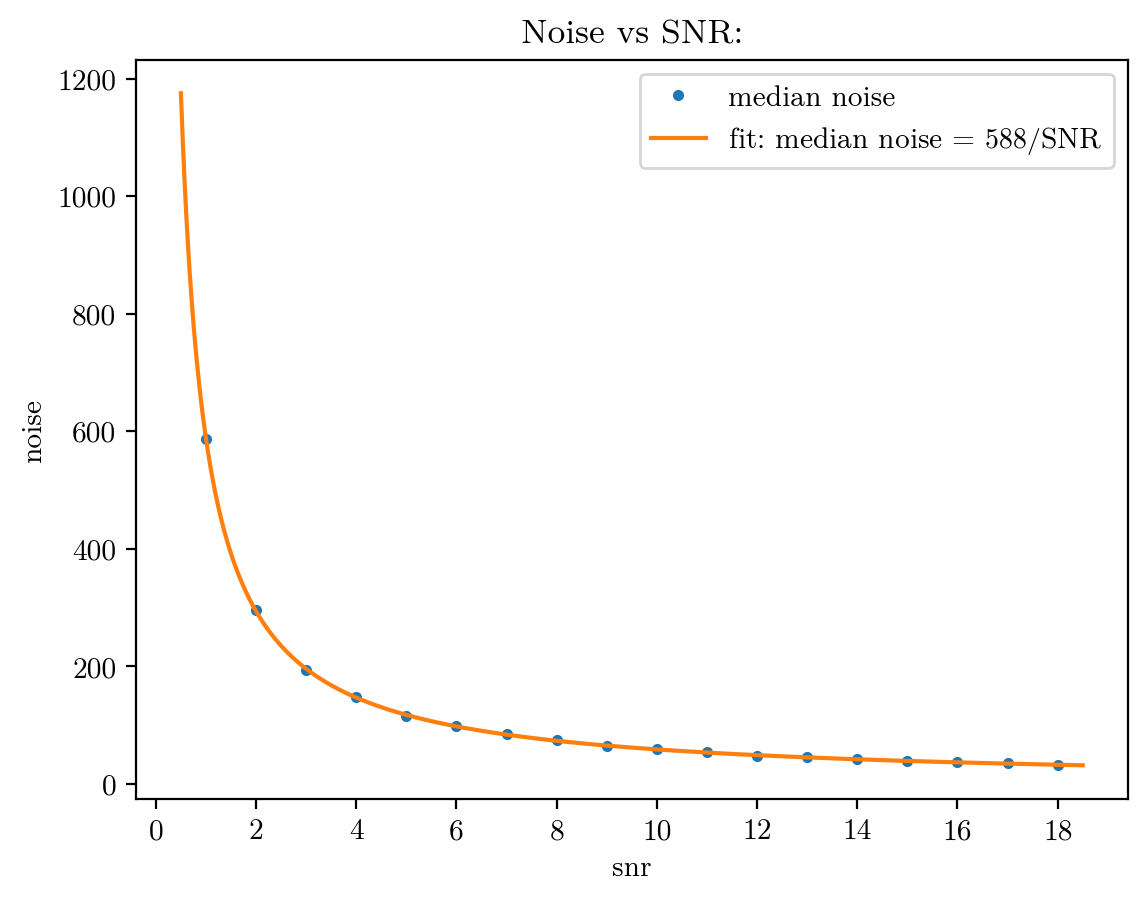

In [43]:
def func(x, a):
    return a/x
plt.plot(snrlevels, median_noise, ".", label="median noise")
params, _ = curve_fit(func, snrlevels, median_noise)
snr_space = np.linspace(snr_range[0]-0.5, snr_range[1]+0.5, 1000)
plt.plot(snr_space, func(snr_space, *params), label=fr"fit: median noise = ${params[0]:.3g} /$SNR")

plt.xlabel("snr")
plt.ylabel("noise")
plt.legend()
plt.title(fr"Noise vs SNR:")
plt.xticks(np.arange(0, 20, 2))
plt.show()

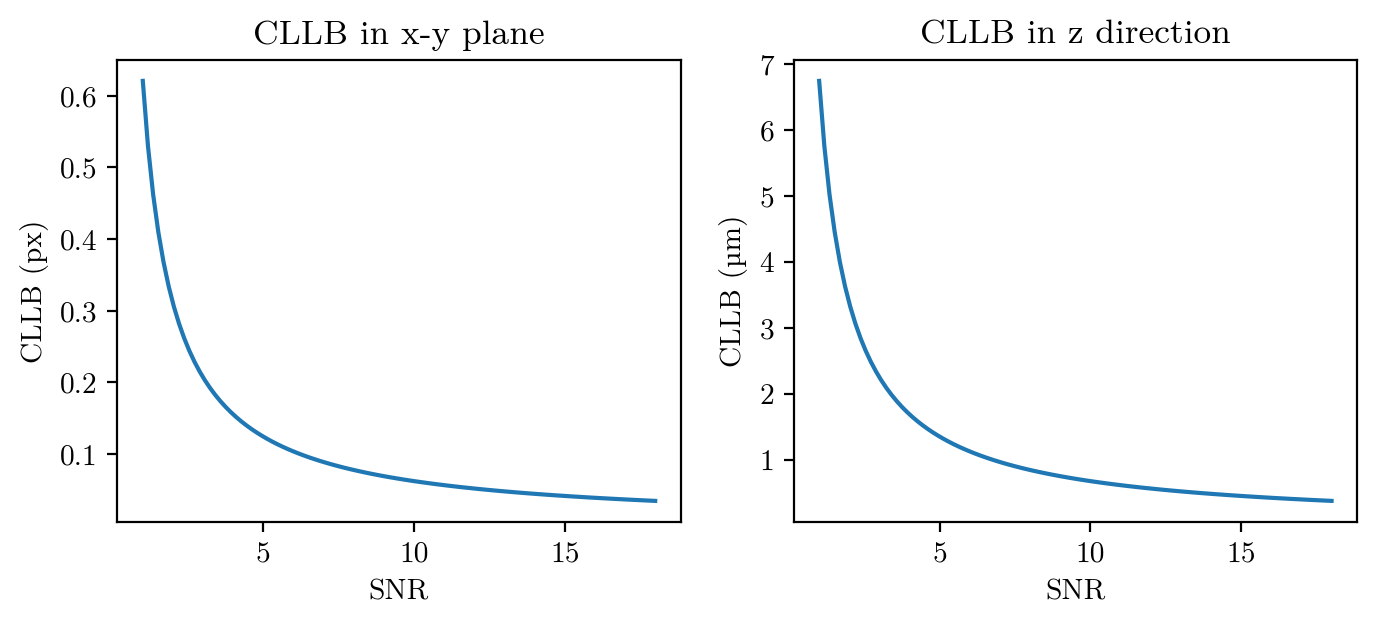

In [3]:
amp=0.75
snr_space = np.linspace(1,18,100)
sigma_noise = 588/snr_space # from fit of snr to noise

mean_lb_z = sigma_noise/amp * np.mean(std_z)
mean_lb_xy = sigma_noise/amp * np.mean(std_xy)

plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.plot(snr_space, mean_lb_xy, label="xy")
plt.xlabel("SNR")
plt.ylabel("CLLB (px)")
plt.title("CLLB in x-y plane")

plt.subplot(1,2,2)
plt.plot(snr_space, mean_lb_z, label="z")
plt.xlabel("SNR")
plt.ylabel("CLLB (µm)")
plt.title("CLLB in z direction")
plt.show()

# Save the results
np.savez("cllb_snr_results.npz", snr_space=snr_space, mean_lb_z=mean_lb_z, mean_lb_xy=mean_lb_xy)